## Description: This notebook performs Gene Regulatory Network (GRN) inference using the pySCENIC workflow. 

In [1]:
import os
import numpy as np
import pandas as pd
import scanpy as sc
import loompy as lp
# import regvelo as rgv
import glob

In [ ]:
# Set scanpy verbosity for cleaner logs
sc.settings.verbosity = 3
# Print versions for reproducibility
sc.logging.print_versions()

-----
anndata     0.10.5.post1
scanpy      1.9.8
-----
PIL                 11.3.0
asttokens           NA
cloudpickle         3.1.1
comm                0.2.3
cycler              0.12.1
cython_runtime      NA
cytoolz             1.0.1
dask                2023.12.1
dateutil            2.9.0.post0
debugpy             1.8.11
decorator           5.2.1
dill                0.4.0
entrypoints         0.4
exceptiongroup      1.3.0
executing           2.2.0
h5py                3.14.0
ipykernel           6.29.5
jedi                0.19.2
jinja2              3.0.3
joblib              1.5.1
kiwisolver          1.4.8
llvmlite            0.41.1
loompy              3.0.8
lz4                 4.4.4
markupsafe          3.0.2
matplotlib          3.7.1
mpl_toolkits        NA
natsort             8.4.0
numba               0.58.0
numexpr             2.11.0
numpy               1.23.0
numpy_groupies      0.11.3
packaging           25.0
pandas              2.0.3
parso               0.8.4
pickleshare         0.7.5


/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/session_info/main.py:213: UserWarning: The '__version__' attribute is deprecated and will be removed in MarkupSafe 3.1. Use feature detection, or `importlib.metadata.version("markupsafe")`, instead.
  mod_version = _find_version(mod.__version__)


## Data Loading & Preprocessing

In [ ]:
# 1. Load the raw count matrix
adata_all = sc.read_mtx("/home/nas2/biod/luyuejing/R/TF_target/filtered_feature_bc_matrix/matrix_all_0.6_6000.mtx")  # 读取矩阵文件
adata_all = adata_all.T  
# 2. Load Gene annotations (Features)
genes = pd.read_csv("/home/nas2/biod/luyuejing/R/TF_target/filtered_feature_bc_matrix/genes_all_0.6_6000.tsv", header=None, sep='\t')
adata_all.var_names = genes[0].values
# 3. Load Cell annotations (Barcodes)
barcodes = pd.read_csv("/home/nas2/biod/luyuejing/R/TF_target/filtered_feature_bc_matrix/barcodes_all_0.6_6000.tsv", header=None, sep='\t')
adata_all.obs_names = barcodes[0].values

adata_all

AnnData object with n_obs × n_vars = 11548 × 1709


AnnData object with n_obs × n_vars = 11548 × 1709

In [ ]:
# 4. Load Metadata / Clustering results
cluster = pd.read_csv("/home/nas2/biod/luyuejing/R/TF_target/filtered_feature_bc_matrix/cell_type_all_0.6_6000.csv", header=0, index_col=0)
cluster

# Extract batch information from barcodes (first 5 characters)
adata_all.obs['batch'] = [name[:5] for name in adata_all.obs_names]

# --- Metadata Processing ---
adata_all.obs_names = [col.replace('data1_', '').replace('data2_', '').replace('data3_', '') for col in adata_all.obs_names]
adata_all.obs['Cluster'] = cluster.loc[adata_all.obs_names, 'cell_type'].values

,cell_type
s_016um_00068_00391-1,AT2 cells
s_016um_00356_00146-1,AT1 cellss
s_016um_00191_00201-1,AM (PBS)
s_016um_00358_00118-1,AM (PBS)
s_016um_00004_00313-1,AT2 cells
...,...
s_016um_00234_00287-1,MDM
s_016um_00373_00244-1,MDM
s_016um_00356_00345-1,MDM
s_016um_00033_00134-1,AT1 cellss


computing neighbors
         Falling back to preprocessing with `sc.pp.pca` and default params.
computing PCA
    with n_comps=30


/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")
/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/anndata/_core/anndata.py:522: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
  warnings.warn(


    finished (0:00:02)


/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:27)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm) (0:00:12)
    using 'X_pca' with n_pcs = 30
Storing dendrogram info using `.uns['dendrogram_Cluster']`


/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/scanpy/plotting/_dotplot.py:747: UserWarning: No data for colormapping provided via 'c'. Parameters 'cmap', 'norm' will be ignored
  dot_ax.scatter(x, y, **kwds)


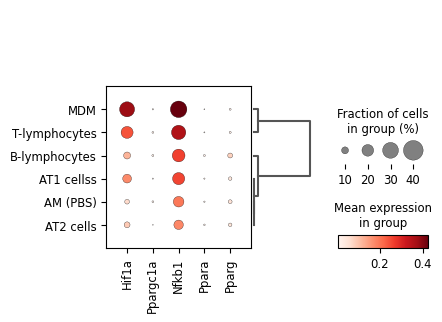

In [ ]:
adata_aaa = adata_all.copy()
sc.pp.neighbors(adata_aaa, n_neighbors=15, n_pcs=30)
sc.tl.umap(adata_aaa)
sc.pl.dotplot(adata_aaa, var_names=['Hif1a','Ppargc1a','Nfkb1',"Ppara","Pparg"], groupby='Cluster',dendrogram=True, show=True)

##  Data Subsetting ##


In [ ]:
adata_AM = adata_all[adata_all.obs['Cluster'] == 'AM (PBS)'] ###("AT1 cellss", "AT2 cells","AM (PBS)","MDM","B-lymphocytes","T-lymphocytes")
adata = adata_AM.copy()
adata

/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


AnnData object with n_obs × n_vars = 1523 × 1709
    obs: 'batch', 'Cluster'

In [12]:
adata = sc.AnnData(adata.X, obs=adata.obs, var=adata.var)
adata.var["Gene"] = adata.var_names
adata.obs["CellID"] =  adata.obs_names
adata.write_loom("./results_6000/results_TF_target_AM/adata.loom")

/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/anndata/_core/anndata.py:1906: UserWarning: Observation names are not unique. To make them unique, call `.obs_names_make_unique`.
  utils.warn_names_duplicates("obs")


## pySCENIC Workflow

### Step 1: GRN Inference (GRNBoost2)

In [ ]:
# path to loom file created previously
f_loom_path_scenic = "./results_6000/results_TF_target_AM/adata.loom"

# path to list of transcription factors
f_tfs = "./data_mm10/allTFs_mm.txt"

In [ ]:
# --- Step 1: Infer Gene Regulatory Network (GRN) ---
# Algorithm: GRNBoost2 (default)
# Input: Expression matrix (.loom) + Transcription Factor list
# Output: Adjacency matrix (TF-Target correlations)
!pyscenic grn {f_loom_path_scenic} {f_tfs} -o "./results_6000/results_TF_target_AM/adj.csv" --num_workers 24

/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution

2025-11-17 19:43:13,685 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2025-11-17 19:43:13,731 - pyscenic.cli.pyscenic - INFO - Inferring regulatory networks.
/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/home/luyuejing/anaconda3/

### Step 2: Regulon Prediction (CisTarget)

In [ ]:
# path to ranking databases in feather format
f_db_glob = "./data_mm10/*feather"
f_db_names = ' '.join( glob.glob(f_db_glob) )

# path to motif databases
f_motif_path = "./data_mm10/motifs-v10nr_clust-nr.mgi-m0.001-o0.0.tbl"

In [ ]:
!pyscenic ctx "./results_6000/results_TF_target_AM/adj.csv" \
    {f_db_names} \
    --annotations_fname {f_motif_path} \
    --expression_mtx_fname {f_loom_path_scenic} \
    --output "./results_6000/results_TF_target_AM/reg.csv" \
    --all_modules \
    --nes_threshold 2.5 \
    --min_genes 5 \
    --top_n_regulators 50 100 200\
    --num_workers 24

/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution

2025-11-17 19:48:11,230 - pyscenic.cli.pyscenic - INFO - Creating modules.

2025-11-17 19:48:11,541 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2025-11-17 19:48:41,004 - pyscenic.utils - INFO - Calculating Pearson correlations.

2025-11-17 19:48:41,135 - pyscenic.utils - WARNING - Note on correlation calculation: the default behaviour for calculating the correlations has changed after pySCENIC verion 0.9.16. Previously, the default was to calculate the correlation between a TF and target gene using only cells with non-zero expression values (mask_dropouts=True). The current d

### Step 3: Cellular Enrichment (AUCell)

In [ ]:
f_pyscenic_output = "./results_6000/results_TF_target_AM/pyscenic_output_all_regulon_no_mask.loom"

In [ ]:
# Calculate the Activity (AUC) of each regulon in each cell
# Output: Updated loom file with 'RegulonsAUC' embedding

!pyscenic aucell \
    {f_loom_path_scenic} \
    "./results_6000/results_TF_target_AM/reg.csv" \
    --output {f_pyscenic_output} \
    --num_workers 4

/home/luyuejing/anaconda3/envs/regvelo/lib/python3.10/site-packages/ctxcore/__init__.py:5: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution

2025-11-17 20:14:12,592 - pyscenic.cli.pyscenic - INFO - Loading expression matrix.

2025-11-17 20:14:12,636 - pyscenic.cli.pyscenic - INFO - Loading gene signatures.
Create regulons from a dataframe of enriched features.
Additional columns saved: []

2025-11-17 20:14:13,404 - pyscenic.cli.pyscenic - INFO - Calculating cellular enrichment.

2025-11-17 20:14:17,335 - pyscenic.cli.pyscenic - INFO - Writing results to file.


## Post-Processing & Binarization

In [ ]:
# 1. Connect to the output loom file
lf = lp.connect(f_pyscenic_output, mode='r+', validate=False)

# 2. Extract AUC Matrix (Cell x Regulon)
auc_mtx = pd.DataFrame(lf.ca.RegulonsAUC, index=lf.ca.CellID)

# 3. Extract Regulon-Gene Target information
regulons = lf.ra.Regulons

print(lf.ca.keys())
print(lf.row_attrs.keys())

['CellID', 'Cluster', 'RegulonsAUC', 'batch', 'obs_names']
['Gene', 'Regulons', 'var_names']


In [ ]:
res = pd.concat([pd.Series(r.tolist(), index=regulons.dtype.names) for r in regulons], axis=1)
res.columns = lf.row_attrs["Gene"]
res.columns
res.to_csv("./results_6000/results_TF_target_AM/regulon_mat_all_regulons.csv")

In [ ]:
# 4. Process into Adjacency Matrix for Downstream tasks
# Reload and clean indices
reg = pd.read_csv("./results_6000/results_TF_target_AM/regulon_mat_all_regulons.csv", index_col = 0)

reg.index = reg.index.str.extract(r"(\w+)")[0]
reg = reg.groupby(reg.index).sum()

In [ ]:
# Binarize the matrix (1 = link exists, 0 = no link)
reg[reg != 0] = 1

# Define universe of TFs and Genes
TF = np.unique(list(map(lambda x: x.split("(")[0], reg.index.tolist())))
genes = np.unique(TF.tolist() + reg.columns.tolist())

In [ ]:
# Create final square GRN matrix (Genes x Genes)
GRN = pd.DataFrame(0, index=genes, columns=genes)
GRN.loc[TF,reg.columns.tolist()] = np.array(reg)

# Filter for active genes (exclude rows/cols with all zeros)
mask = (GRN.sum(0) != 0) | (GRN.sum(1) != 0)
GRN = GRN.loc[mask, mask].copy()

# Save as Parquet 
GRN.to_parquet("./results_6000/results_TF_target_AM/regulon_mat_processed_all_regulons.parquet")
print("Done! processed GRN with " + str(reg.shape[0]) + " TFs and " + str(reg.shape[1]) + " targets")

Done! processed GRN with 75 TFs and 1709 targets
